# 🚗 Deteksi Plat Nomor Kendaraan dengan YOLOv11 dan EasyOCR

Notebook ini mengimplementasikan sistem ANPR (Automatic Number Plate Recognition) atau deteksi plat nomor dengan menggunakan:
- **YOLOv11** (dari Ultralytics) untuk mendeteksi bounding box plat nomor.
- **EasyOCR** untuk mengekstrak teks dari area plat.

## 1. Instalasi Paket yang Dibutuhkan

Jalankan cell berikut untuk menginstal library yang diperlukan (jika belum terinstal).

In [1]:
!pip install --upgrade ultralytics easyocr opencv-python numpy matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Tes Coba PyTorch CPU version
import torch
print(f"Versi Torch: {torch.__version__}")
# Coba buat tensor sederhana untuk memastikan tidak error
a = torch.tensor([1.0, 2.0]).to("cpu")
print("PyTorch berjalan normal!")

Versi Torch: 2.4.1+cpu
PyTorch berjalan normal!


## 2. Import Semua Library

Import modul yang akan digunakan:
- `cv2` untuk pemrosesan gambar/video.
- `torch` untuk deteksi device (CPU/GPU).
- `easyocr` untuk OCR.
- `numpy` untuk operasi array.
- `YOLO` dari ultralytics untuk model deteksi.
- `Annotator` dan `colors` untuk visualisasi bounding box.

In [3]:
import cv2
import torch
import easyocr
import numpy as np
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator, colors
import matplotlib.pyplot as plt

## 3. Cek Device (CPU / CUDA)

Kita cek apakah GPU tersedia agar proses lebih cepat.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

Device yang digunakan: cpu


## 4. Kelas ANPR – Inisialisasi

Buat kelas `ANPR` atau Deteksi Plat Nomor yang akan memuat:
- Model YOLO (dengan path yang bisa diatur).
- Reader EasyOCR (dengan bahasa Inggris).

Pastikan file model `anpr_best.pt` (atau model yang sudah dilatih untuk plat) berada di direktori yang sama, source : https://www.youtube.com/watch?v=Fym4hoaoreE&t=42s


In [43]:
import os
model_path = "anpr_best.pt"  # atau path absolut Anda
if os.path.exists(model_path):
    print("✅ File ditemukan!")
else:
    print("❌ File tidak ditemukan, cek path-nya!")

✅ File ditemukan!


## 5. Metode Inferensi Video

Fungsi `detect_plates()` menerima gambar (`im0`) dan mengembalikan bounding box dari plat nomor yang terdeteksi.

Fungsi `extract_text()` memotong area plat berdasarkan bounding box, lalu melakukan OCR menggunakan EasyOCR.
- Gambar diubah ke grayscale untuk meningkatkan akurasi.
- Plat warna hitam terkadang agak sulit dan harus setting threshold agar terbaca.

Fungsi `infer_video()` melakukan pemrosesan real-time pada video (dari file atau webcam).
- Baca frame per frame.
- Deteksi plat dan OCR.
- Tampilkan hasil dengan bounding box dan teks.
- Simpan output video jika diinginkan.

In [47]:
class ANPR:
    
    def __init__(self, model_path: str = r"D:\Python\anpr_best.pt"):  # ganti dengan path Anda
        """Inisialisasi ANPR dengan model YOLO dan EasyOCR."""
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = YOLO(model_path)
        self.reader = easyocr.Reader(["en"], gpu=torch.cuda.is_available())
        print(f"Model YOLO dimuat dari: {model_path}")
        print(f"EasyOCR siap digunakan.")
        
    def detect_plates(self, im0: np.ndarray):
        results = self.model.predict(im0, verbose=False)
        boxes = results[0].boxes.xyxy.cpu().numpy() if results and results[0].boxes is not None else []
        return boxes

    def extract_text(self, im0: np.ndarray, bbox: np.ndarray):
        x1, y1, x2, y2 = map(int, bbox)
        roi = im0[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        text = self.reader.readtext(gray, detail=0, paragraph=True)
        return " ".join(text).strip() if text else ""

    def infer_video(self, source: str = 0, output_path: str = None, display: bool = True):
        cap = cv2.VideoCapture(source)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video source: {source}")
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        writer = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        print("🚀 Memulai inferensi video... Tekan 'q' untuk keluar.")
        while True:
            ret, im0 = cap.read()
            if not ret:
                break
            boxes = self.detect_plates(im0)
            ann = Annotator(im0, line_width=4)
            for bbox in boxes:
                text = self.extract_text(im0, bbox)
                ann.box_label(bbox, label=text, color=colors(17, True))
            if display:
                cv2.imshow("ANPR (Press 'q' to exit)", im0)
            if writer:
                writer.write(im0)
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
        cap.release()
        if writer:
            writer.release()
        cv2.destroyAllWindows()

In [48]:
# Pastikan Cell A sudah menunjukkan "File ditemukan" sebelum menjalankan ini
anpr = ANPR(model_path="anpr_best.pt")  # sesuaikan path-nya

Using CPU. Note: This module is much faster with a GPU.


Model YOLO dimuat dari: anpr_best.pt
EasyOCR siap digunakan.


## 6. Inferensi pada Video

Jalankan ANPR pada file video `videos.mp4` dan simpan hasilnya ke `anpr_output.mp4`.  
Anda juga bisa mengganti `source` dengan angka `0` untuk webcam.

In [46]:
# Pastikan file video ada di path yang benar
anpr.infer_video(source="bmw_60fps.mp4", output_path="anpr_output.mp4", display=True)

🚀 Memulai inferensi video... Tekan 'q' untuk keluar.


## 7. (Opsional) Deteksi pada Gambar Statis

Jika Anda ingin mencoba pada satu gambar, gunakan kode berikut.

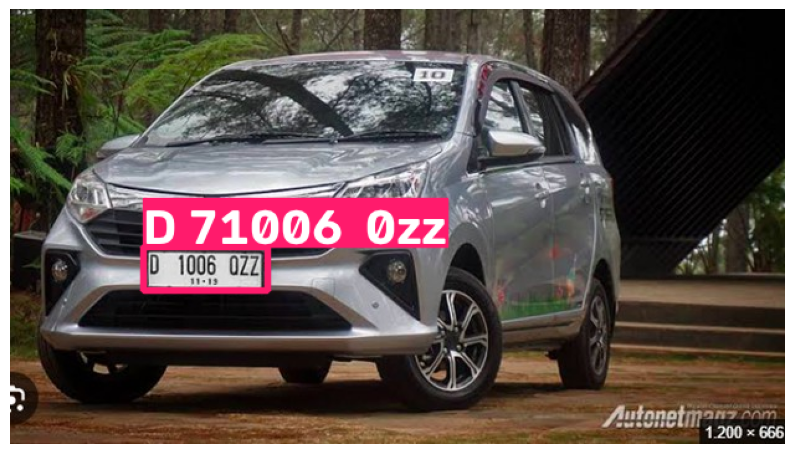

In [28]:
def infer_image(image_path, model, reader):
    im0 = cv2.imread(image_path)
    if im0 is None:
        print("Gambar tidak ditemukan.")
        return
    boxes = model.detect_plates(im0)
    ann = Annotator(im0, line_width=4)
    for bbox in boxes:
        text = model.extract_text(im0, bbox)
        ann.box_label(bbox, label=text, color=colors(17, True))
    # Tampilkan dengan matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(im0, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Contoh penggunaan:
infer_image(r"D:\Python\contoh_plat.jpg", anpr, anpr.reader)

## 8. Ringkasan

- **YOLOv11** mendeteksi lokasi plat nomor dengan cepat dan akurat.
- **EasyOCR** membaca teks dari area yang terdeteksi.
- Kombinasi keduanya menghasilkan sistem ANPR yang handal.

Selamat mencoba gaess! 
- **Made by Brilitech**